In [1]:
# ==============================
# STEP 1: LOAD + INFO
# ==============================

import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('housing.csv')

# Basic info
print(df.head())
print("\nINFO:\n")
print(df.info())

print("\nDESCRIPTION:\n")
print(df.describe())

Saving housing.csv to housing.csv
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

INFO:

<class 'pandas.core.frame.DataFra

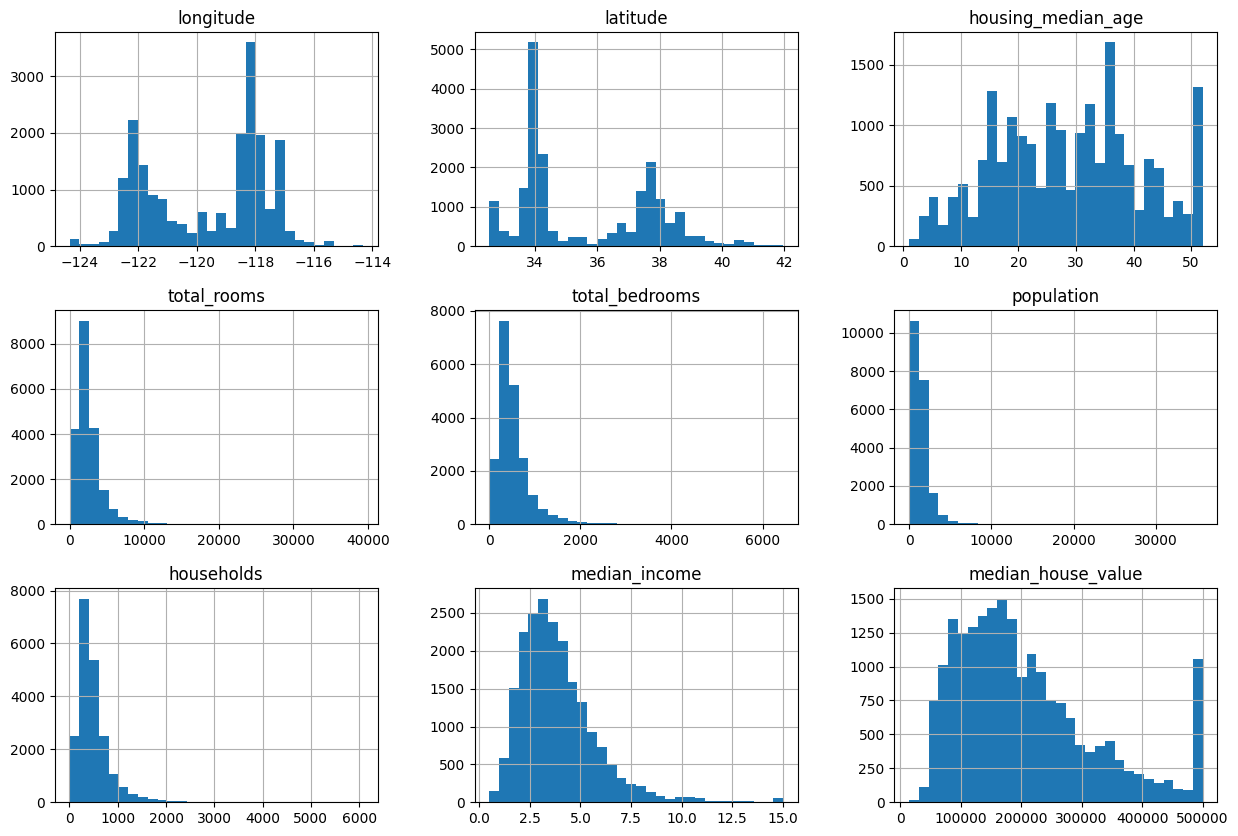

In [2]:
# ==============================
# STEP 2: HISTOGRAMS
# ==============================

import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15,10))
plt.show()

In [5]:
# ==============================
# RANDOM SPLIT
# ==============================

import numpy as np
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# ==============================
# STRATIFIED SPLIT
# ==============================

df["income_cat"] = pd.cut(df["median_income"],
                         bins=[0,1.5,3,4.5,6,np.inf],
                         labels=[1,2,3,4,5])

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(df, df["income_cat"]):
    strat_train = df.loc[train_idx]
    strat_test = df.loc[test_idx]

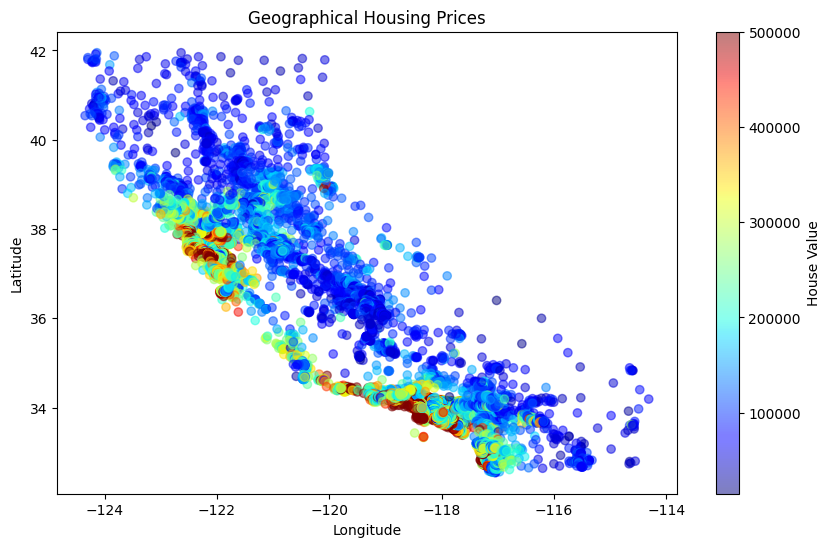

In [6]:
# ==============================
# GEO GRAPH
# ==============================

plt.figure(figsize=(10,6))
plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value"],
            cmap="jet", alpha=0.5)

plt.colorbar(label="House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Housing Prices")
plt.show()

In [7]:
# ==============================
# CORRELATION
# ==============================

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


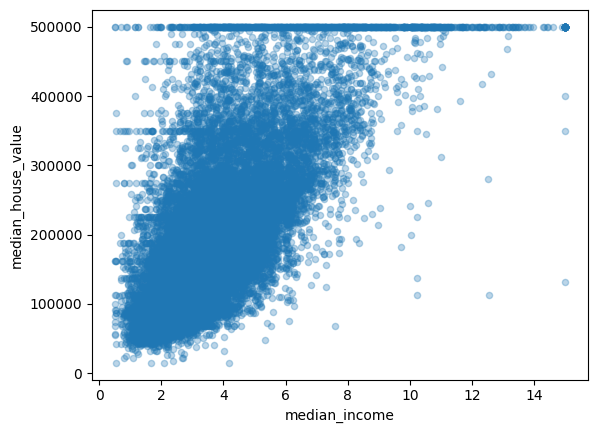

In [8]:
# Plot best feature
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.3)
plt.show()

In [9]:
# ==============================
# FEATURE COMBINATION
# ==============================

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value     1.000000
median_income          0.688075
rooms_per_household    0.151948
total_rooms            0.134153
housing_median_age     0.105623
households             0.065843
total_bedrooms         0.049686
population            -0.024650
longitude             -0.045967
latitude              -0.144160
bedrooms_per_room     -0.255880
Name: median_house_value, dtype: float64


In [11]:
# ==============================
# ENCODING
# ==============================

from sklearn.preprocessing import OneHotEncoder

df_cat = df[["ocean_proximity"]]

encoder = OneHotEncoder()
df_encoded = encoder.fit_transform(df_cat)

print(df_encoded.toarray()[:5])

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]


In [12]:
# ==============================
# SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

num_cols = df.drop("ocean_proximity", axis=1)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_cols)

print(scaled_data[:5])

[[-1.32783522  1.05254828  0.98214266 -0.8048191  -0.97247648 -0.9744286
  -0.97703285  2.34476576  2.12963148  1.89012782  0.62855945 -1.1460242 ]
 [-1.32284391  1.04318455 -0.60701891  2.0458901   1.35714343  0.86143887
   1.66996103  2.33223796  1.31415614  1.89012782  0.32704136 -0.98725423]
 [-1.33282653  1.03850269  1.85618152 -0.53574589 -0.82702426 -0.82077735
  -0.84363692  1.7826994   1.25869341  1.89012782  1.15562047 -1.44051403]
 [-1.33781784  1.03850269  1.85618152 -0.62421459 -0.71972345 -0.76602806
  -0.73378144  0.93296751  1.16510007  0.94189394  0.15696608 -0.49292537]
 [-1.33781784  1.03850269  1.85618152 -0.46240395 -0.61242263 -0.75984669
  -0.62915718 -0.012881    1.17289952 -0.00633994  0.3447108  -0.70614112]]


In [13]:
# ==============================
# PIPELINE
# ==============================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prepared_data = pipeline.fit_transform(num_cols)

print(prepared_data[:5])

[[-1.32783522  1.05254828  0.98214266 -0.8048191  -0.97247648 -0.9744286
  -0.97703285  2.34476576  2.12963148  1.89012782  0.62855945 -1.14993031]
 [-1.32284391  1.04318455 -0.60701891  2.0458901   1.35714343  0.86143887
   1.66996103  2.33223796  1.31415614  1.89012782  0.32704136 -0.99038135]
 [-1.33282653  1.03850269  1.85618152 -0.53574589 -0.82702426 -0.82077735
  -0.84363692  1.7826994   1.25869341  1.89012782  1.15562047 -1.44586501]
 [-1.33781784  1.03850269  1.85618152 -0.62421459 -0.71972345 -0.76602806
  -0.73378144  0.93296751  1.16510007  0.94189394  0.15696608 -0.49362714]
 [-1.33781784  1.03850269  1.85618152 -0.46240395 -0.61242263 -0.75984669
  -0.62915718 -0.012881    1.17289952 -0.00633994  0.3447108  -0.707889  ]]
